C:\Users\mjsva\iCloudDrive\1612.nl\Code\src\load\total.py:121: FutureWarning: Minute.delta is deprecated and will be removed in a future version. Use pd.Timedelta(obj) instead
  window_size = int(window_days * 24 * 60 / (df.index.freq.delta.total_seconds() / 60))
C:\Users\mjsva\iCloudDrive\1612.nl\Code\src\load\total.py:121: FutureWarning: Minute.delta is deprecated and will be removed in a future version. Use pd.Timedelta(obj) instead
  window_size = int(window_days * 24 * 60 / (df.index.freq.delta.total_seconds() / 60))


,P_heat_kW,P_cool_kW,P_elektro_kW,P_process_kW,P_mobility_kW,P_overig_kW,P_total_kW
2024-01-01 00:00:00+01:00,17.356210,0.0,7.5,0.0,0.0,1.25,26.106210
2024-01-01 00:15:00+01:00,17.448958,0.0,7.5,0.0,0.0,1.25,26.198958
2024-01-01 00:30:00+01:00,16.750058,0.0,7.5,0.0,0.0,1.25,25.500058
2024-01-01 00:45:00+01:00,16.071521,0.0,7.5,0.0,0.0,1.25,24.821521
2024-01-01 01:00:00+01:00,19.478638,0.0,7.5,0.0,0.0,1.25,28.228638


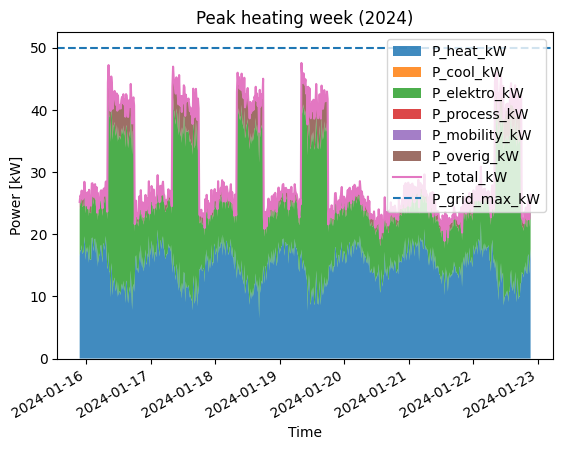

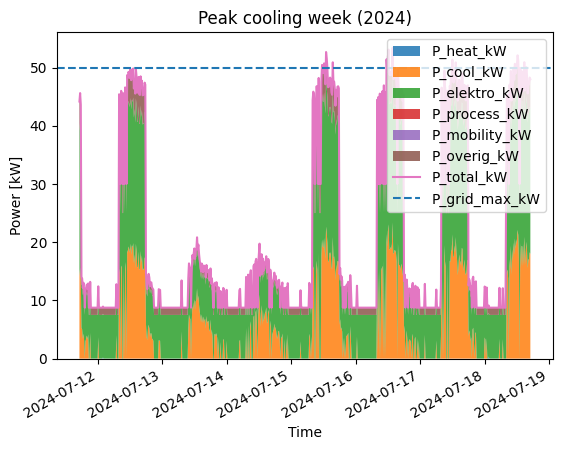

In [4]:
import sys
from pathlib import Path

# voeg projectroot toe (pas aan als je notebook elders staat)
PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.load import (
    BuildingType, YearClass, Orientation8,
    make_default_load_config, run_load_simulation
)
from src.load.total import make_year_index
from src.load.weather import make_typical_weather

# 0) maak index en weather
index = make_year_index(2024, freq="15min", tz="Europe/Amsterdam")
weather = make_typical_weather(index)  # heeft t_amb_C, wind_ms, ghi_Wm2

# 1) maak config (defaults)
cfg = make_default_load_config(
    building_type=BuildingType.OFFICE,
    #year_class=YearClass.PRE_1992,
    #year_class=YearClass.Y1992_2005,
    year_class=YearClass.Y2006_2014,
    #year_class=YearClass.Y2015_PLUS,
    bvo_m2=2500,
    orientation=Orientation8.N,
    # overrides voorbeeld:
    building_overrides={"t_heat_set_C": 19.0, "t_cool_set_C": 21.0},
    pelektro_overrides={"p_occ_W_per_m2": 10.0},
)

# 2) run simulatie (weather=None is ok voor nu; dummy forcing)
df, fig_heat, fig_cool, debug = run_load_simulation(
    cfg,
    year=2024,
    freq="15min",
    grid_cap_kW=50,
    weather=weather,      
    include_debug=False,
)

df.head()